<a href="https://colab.research.google.com/github/xAn-x/Cifar-10-image-classification/blob/master/02.2_Language_Modeling_using_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

In [ ]:
# conect with my drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path="/content/drive/MyDrive/Datasets/names.txt"
with open(dataset_path,"r") as file:
  names=file.read().splitlines()

In [ ]:
names[:5]

['Aaren', 'Aarika', 'Abagael', 'Abagail', 'Abbe']

In [ ]:
characters="abcdefghijklmnopqrstuvwxyz"
special_token="<special>"
unknown_token="<unknown>"
vocab=[special_token,unknown_token]+list(characters)

In [ ]:
vocab_size=len(vocab)
vocab_size

28

In [ ]:
# Creating mapping
stoi={ch:i for i,ch in enumerate(vocab)}
itos={i:ch for ch,i in stoi.items()}

In [ ]:
block_size=3
emb_size=7
vocab_size

28

In [ ]:
from collections import deque
def createDataset():
  X,y=[],[]
  for name in names:
    word=list(name.lower())+[special_token]
    word_len=len(word)
    dq=deque([stoi[special_token]]*block_size,maxlen=block_size)
    for i in range(word_len):
      X.append(list(dq))
      next_char=stoi.get(word[i],stoi[unknown_token])
      y.append(next_char)
      dq.append(next_char)
  return torch.tensor(X),torch.tensor(y)

In [ ]:
X,y=createDataset()

In [ ]:
X[:3]

tensor([[0, 0, 0],
        [0, 0, 2],
        [0, 2, 2]])

In [ ]:
X.shape,y.shape

(torch.Size([35148, 3]), torch.Size([35148]))

## Layers of torch.nn from scratch

In [ ]:
import torch
import torch.nn.functional as F

In [ ]:
class Linear:
    def __init__(self, inp, out, bias=True):
        self.wts = torch.randn(inp,out,requires_grad=True)
        self.has_bias = bias
        if bias:
            self.bias = torch.randn(1,out,requires_grad=True)

    def __call__(self, x):
        x=x.float()
        out = x @ self.wts
        if self.has_bias:
            out += self.bias
        return out

    def parameters(self):
        parameters = [self.wts]
        if self.has_bias:
            parameters.append(self.bias)
        return parameters


In [ ]:
# BatchNorm layer
class BatchNorm:
    def __init__(self, num_features, epsilon=1e-5, momentum=0.9):
        self.epsilon = epsilon
        self.momentum = momentum
        self.training=True

        self.alpha = torch.tensor(np.random.rand(1, num_features),requires_grad=True)
        self.beta = torch.tensor(np.random.rand(1, num_features),requires_grad=True)
        # initially running means and var will be 0
        self.running_mean = torch.zeros((1, num_features))
        self.running_var = torch.zeros((1, num_features))

    def __call__(self, x):
        if self.training:
            mean = torch.mean(x, dim=0)
            var = torch.var(x, dim=0)
        else :
            mean = self.running_mean
            var = self.running_var

        x_std= (x-mean)/torch.sqrt(var+self.epsilon)
        self.out=self.alpha*x_std+self.beta

        if self.training:
          with torch.no_grad():
          # use momentum to calc new running mean
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var

        return self.out

    def parameters(self):
        return [self.alpha, self.beta]


In [ ]:
# Tanh layer
class Tanh():
  def __call__(self,x):
    return torch.tanh(x)

  def parameters(self):
    return []

In [ ]:
# Embedding Layer
class Embedding:
    def __init__(self, inp_size, emb_size):
        self.embeddings =torch.randn(inp_size,emb_size,requires_grad=True)

    def __call__(self, x):
        x=x.int()
        return self.embeddings[x]

    def parameters(self):
        return [self.embeddings]


In [ ]:
# Flatten Layer
class Flatten:
  def __call__(self,x):
    return x.view(x.shape[0],-1)

  def parameters(self):
    return []

In [ ]:
# Sequential Container
class Sequential:
  def __init__(self,layers):
    self.layers=layers

  def __call__(self,x):
    for layer in self.layers:
      x=layer(x)
    return x

  def parameters(self):
    all_parameters = []
    for layer in self.layers:
        layer_parameters = layer.parameters()
        all_parameters.extend(layer_parameters)
    return all_parameters

  def to(self, device):
      for layer in self.layers:
          layer.to(device)

In [ ]:
## Making Infrence

In [ ]:
model=Sequential([
    Embedding(vocab_size,emb_size),
    Flatten(),
    Linear(emb_size*block_size,200),
    Tanh(),
    BatchNorm(200),
    Linear(200,vocab_size)
])

In [ ]:
for idx,layer in enumerate(model.layers):
    layer_name = layer.__class__.__name__
    parameters = layer.parameters()
    print(f"Layer-{idx+1}: {layer_name}")
    for param in parameters:
        print(f"Parameter shape: {param.shape}")
    print()

Layer-1: Embedding
Parameter shape: torch.Size([28, 7])

Layer-2: Flatten

Layer-3: Linear
Parameter shape: torch.Size([21, 200])
Parameter shape: torch.Size([1, 200])

Layer-4: Tanh

Layer-5: BatchNorm
Parameter shape: torch.Size([1, 200])
Parameter shape: torch.Size([1, 200])

Layer-6: Linear
Parameter shape: torch.Size([200, 28])
Parameter shape: torch.Size([1, 28])



In [ ]:
global_loss = []

In [ ]:
def train(model, X, y, epochs, lr=0.01, batch_size=256):

    global global_loss

    n = X.shape[0]
    opt = torch.optim.SGD(model.parameters(), lr=lr)

    loss = []

    for epoch in range(epochs):
        indices = torch.randint(0, n, size=(batch_size,))
        X_min_batch = X[indices]
        y_min_batch = y[indices]

        # Forward pass
        logits = model(X_min_batch)
        loss = F.cross_entropy(logits, y_min_batch)

        if (epoch+1) % 1_000 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

        # Append loss to global loss list
        global_loss.append(loss.item())

        # Backward pass
        loss.backward()

        # step
        opt.step()
        opt.zero_grad()


    print(np.mean(global_loss))

In [ ]:
n=int(1e4)
train(model,X,y,n)

Epoch [1000/10000], Loss: 2.7633
Epoch [2000/10000], Loss: 2.5613
Epoch [3000/10000], Loss: 2.4125
Epoch [4000/10000], Loss: 2.4211
Epoch [5000/10000], Loss: 2.4720
Epoch [6000/10000], Loss: 2.5099
Epoch [7000/10000], Loss: 2.4715
Epoch [8000/10000], Loss: 2.2959
Epoch [9000/10000], Loss: 2.2995
Epoch [10000/10000], Loss: 2.3715
2.6558436485767363


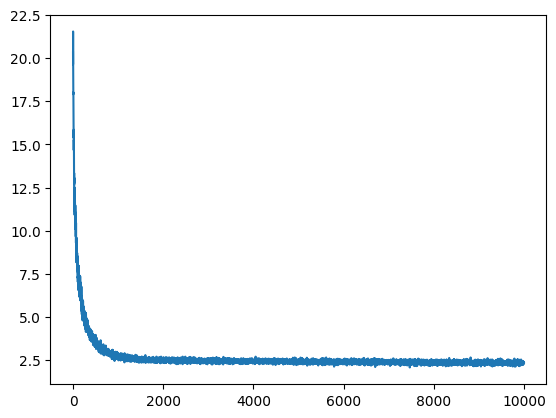

In [ ]:
plt.plot(np.arange(0,len(global_loss)),global_loss)

In [ ]:
g=torch.Generator().manual_seed(314159)

@torch.no_grad
def genNames(n):

    # Putting batch-norm in testing-mode
    for layer in model.layers:
      if isinstance(layer,BatchNorm):
        layer.training=False;

    for i in range(n):
      context = [stoi[special_token]] * block_size
      out=[]
      while True:
        inp_batch=torch.tensor([context])
        logits=model(inp_batch)
        probs=F.softmax(logits,dim=1)
        ix=ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # special-schar @ end
        if ix==0:
          break

        context=context[1:]+[ix]
        out.append(ix)

      print("".join(itos[i] for i in out))

    # Putting batch-norm in Trainin-mode again
    for layer in model.layers:
      if isinstance(layer,BatchNorm):
        layer.training=True;

In [ ]:
genNames(20)

nesay
caill
oweliolynene
barnetterisc
rdcindahenpidadimeea
acmndinite
gaplo
aeynthneaeamicy
ncvochakelia
fatmne
madlla
serala
ku
delde
gisayrtaine
vra
erdonam
kchelia
dusbinnc
lana


In [ ]:
# This Model is not better than bigram model but more flexible we can alter it architecture to make it to more